## Noise Bliss
###### https://github.com/calanuzao/noise-bliss
Denoising Algorithms for Acoustic Scene Classification in Deep Learning Models with the SONYC-UST Dataset

In [1]:
# libraries
import utils as u
import models as m 

# apis
import IPython.display as ipd
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import torch
import torchaudio

In [2]:
# tensorflow and tensorflow-metal
import tensorflow as tf
print("TensorFlow Version: ", tf.__version__)
print("Is GPU available: ", tf.config.list_physical_devices("GPU"))

TensorFlow Version:  2.19.0
Is GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Defining data directory and and structure.

In [3]:
import os 
import numpy as np 
import pandas as pd

# change path ccordingly
data_home = '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust'

# annotations
annotations_df = pd.read_csv(os.path.join(data_home, 'annotations.csv'))

if os.path.exists(data_home):
    # First, check if audio files are extracted
    audio_dir = os.path.join(data_home, 'audio')
    if not os.path.exists(audio_dir):
        print("Extract the audio files with script (unpack_audio.sh)")
    else:
        # Load audio files and labels
        audio_files, labels = u.load_data(audio_dir)
        print("Total number of audio files:", len(audio_files))
        print("\nSample audio files:")
        print(audio_files[:5])
        print("\nSample annotations:")
        print(annotations_df.head())

else:
    print('Data directory not found.')

Total number of audio files: 18510

Sample audio files:
['/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/29_001349.wav'
 '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/37_007954.wav'
 '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_010868.wav'
 '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/34_013522.wav'
 '/Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/01_009487.wav']

Sample annotations:
  split  sensor_id audio_filename  annotator_id  borough  block  latitude  \
0  test          0  00_026884.wav            -6        1    547  40.72951   
1  test          0  00_026884.wav            -4        1    547  40.72951   
2  test          0  00_026884.wav            -3        1    547  40.72951   
3  test          0  00_026884.wav            -1        1    547  40.72951   
4  test          0  00_026884.wav             0        1    547  40.72951   

   longitude  

#### Understanding and Plotting Data.

Train sensors       : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}
Validate sensors    : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}
Test sensors        : {1, 2, 8, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45}


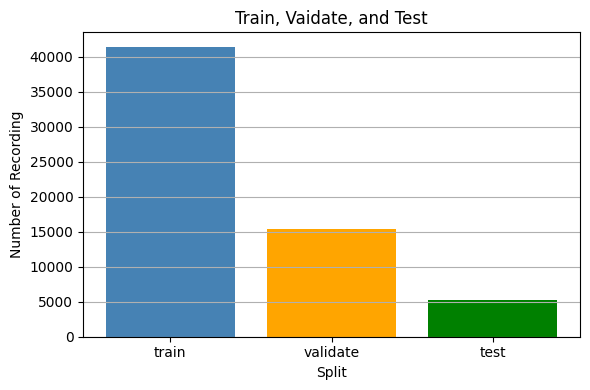

In [4]:
# plotting data
train_df = annotations_df[annotations_df['split'] == 'train']
valid_df = annotations_df[annotations_df['split'] == 'validate']
test_df = annotations_df[annotations_df['split'] == 'test']

# printing sensor sets
print("Train sensors       :", set(train_df['sensor_id']))
print("Validate sensors    :", set(train_df['sensor_id']))
print("Test sensors        :", set(train_df['sensor_id']))

# counting reading per split
split_counts = annotations_df['split'].value_counts().reindex(
    ['train', 'validate', 'test'], fill_value=0
)

# plotting recordings
plt.figure(figsize=(6, 4))
colors = ['steelblue', 'orange', 'green']
plt.bar(split_counts.index, split_counts.values, color=colors[:len(split_counts)])

plt.title('Train, Vaidate, and Test')
plt.xlabel('Split')
plt.ylabel('Number of Recording')
plt.grid(axis='y')
plt.tight_layout()
plt.legend
plt.show()

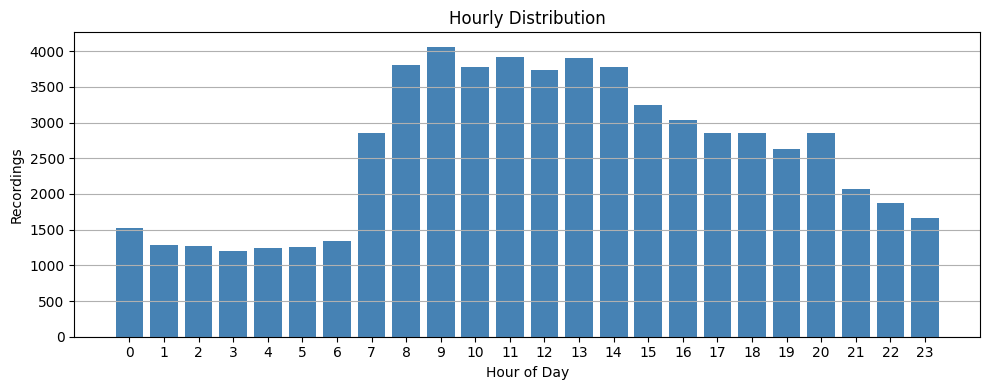

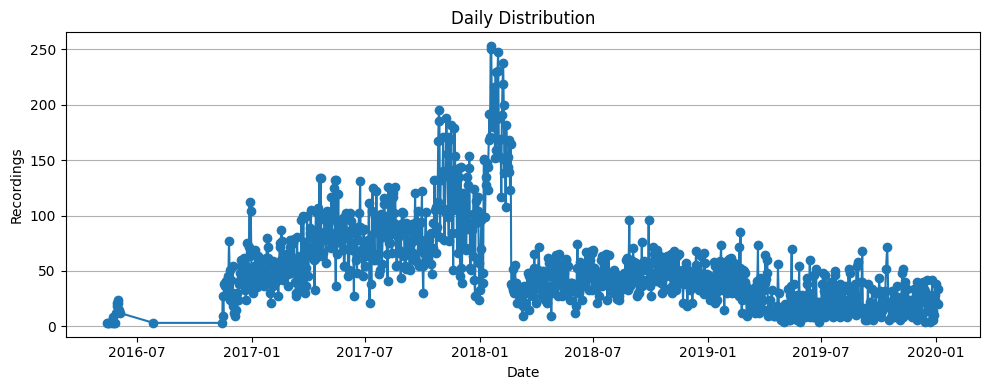

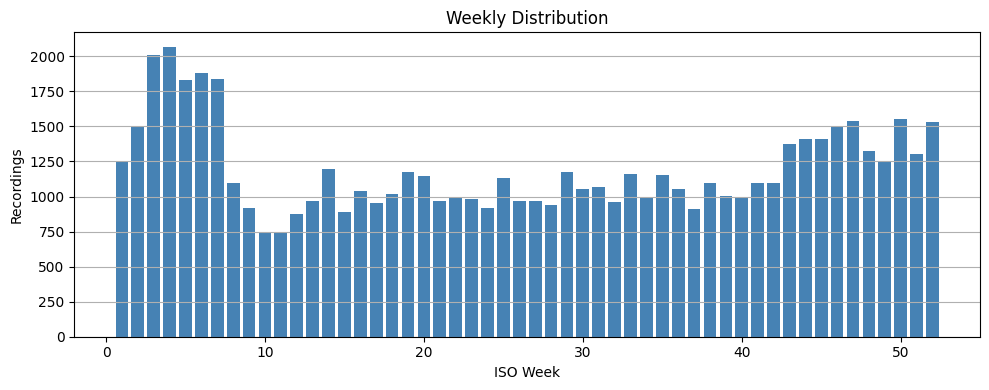

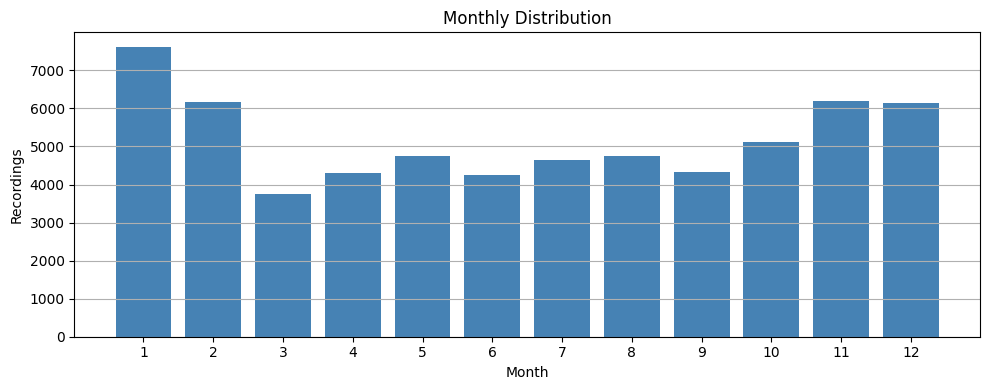

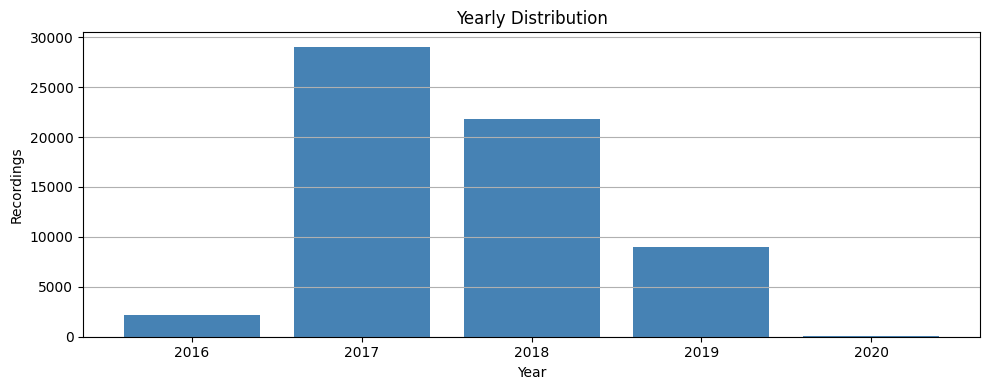

In [5]:
# plotting temporal data 
annotations_df = u.construct_datetime(annotations_df)
u.compute_and_plot_distributions(annotations_df)

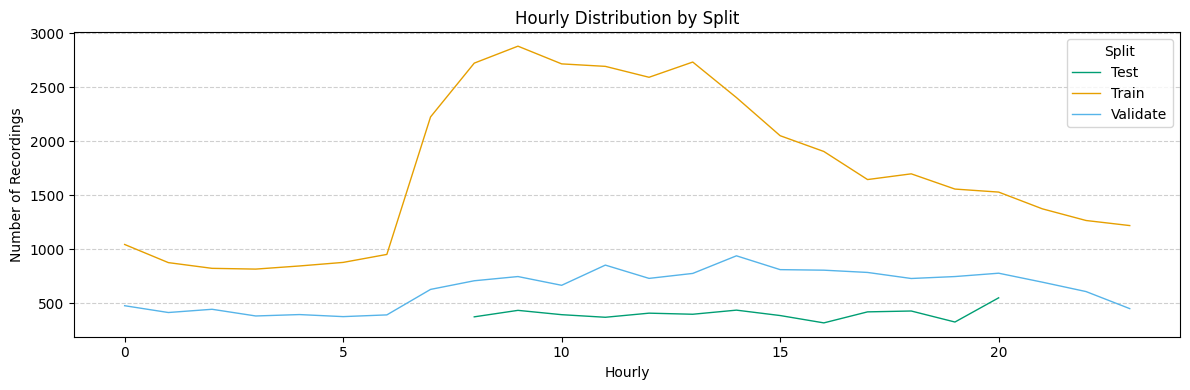

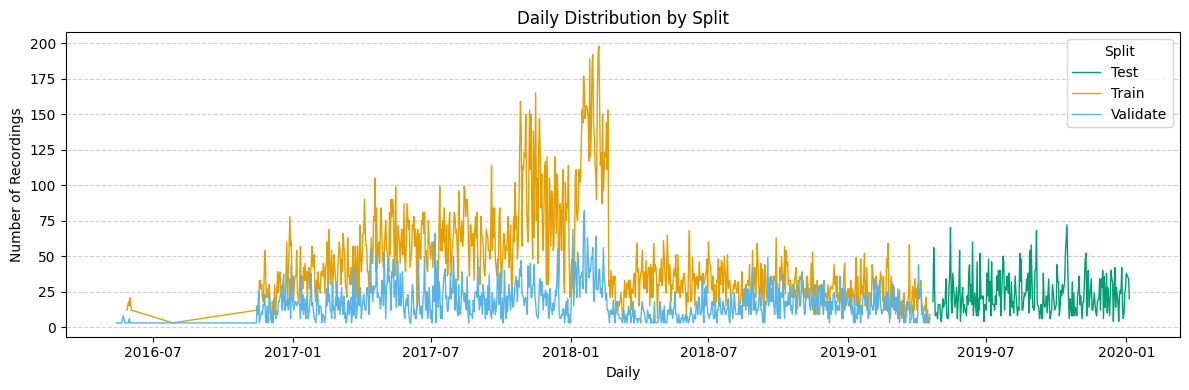

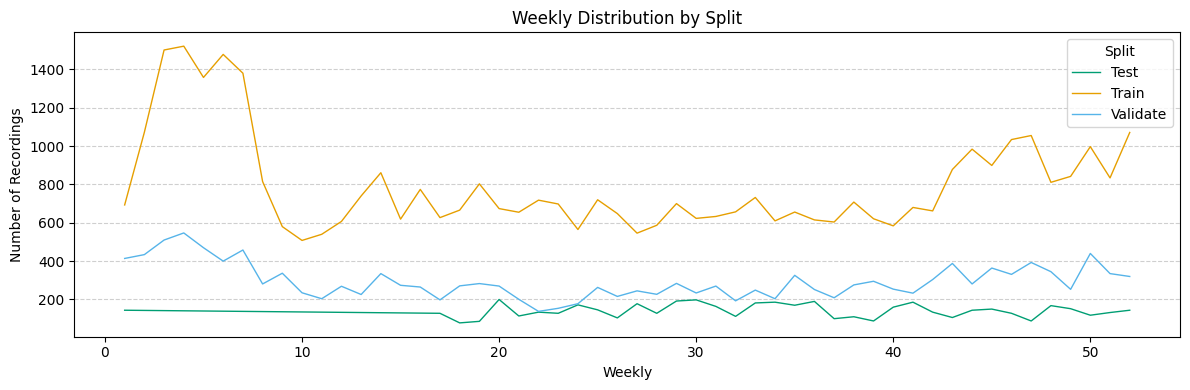

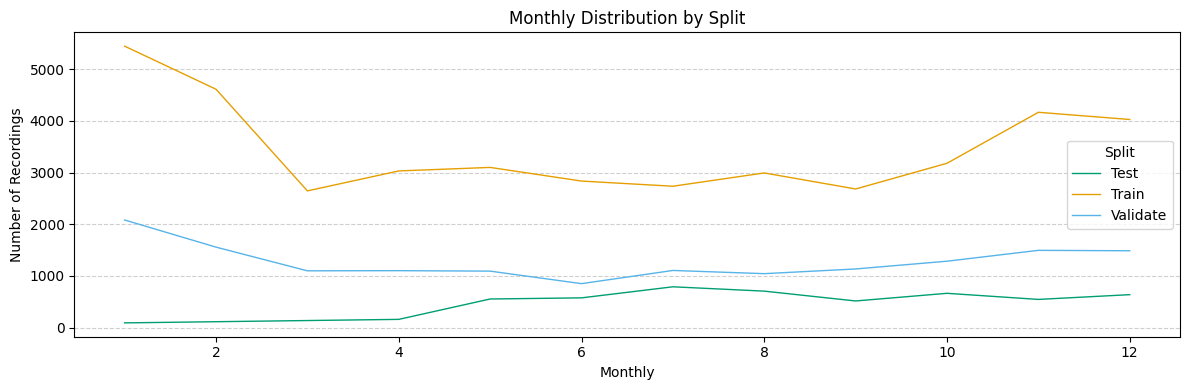

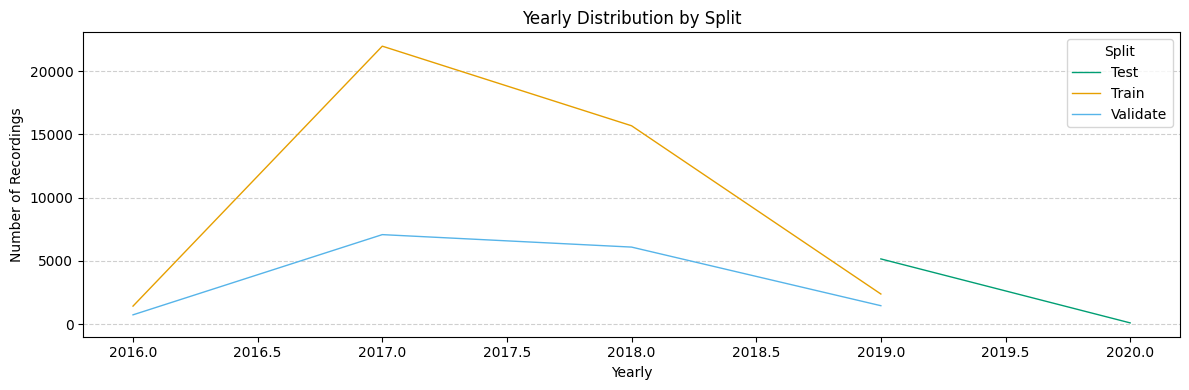

In [6]:
# plotting temporal data by split
u.plot_distributions_by_split(annotations_df)

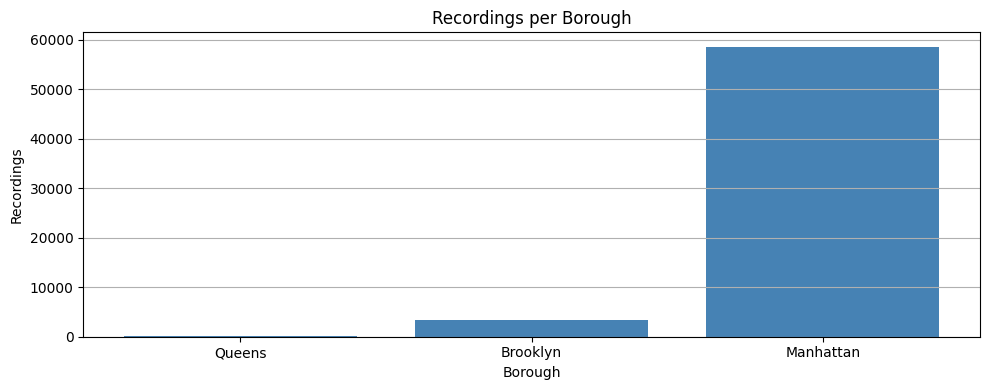

In [7]:
# borough mapping
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

# Map borough ID to name
annotations_df['borough_name'] = annotations_df['borough'].map(borough_map)

# Count number of recordings per borough (with data)
borough_counts = annotations_df['borough_name'].value_counts().sort_index()

# Order from greatest to least
ordered_boroughs = [name for id_, name in borough_map.items() if name in borough_counts.index]
borough_counts = borough_counts[ordered_boroughs]
borough_counts = borough_counts.sort_values(ascending=True)

# ---------- Plot ----------
u.plot_distribution(
    borough_counts,
    xlabel="Borough",
    ylabel="Recordings",
    title="Recordings per Borough"
)

/var/folders/7s/4_xdxsgd3g717br165rj0xy00000gn/T/ipykernel_10104/3141741249.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ordered_sensors.groupby('borough_name')


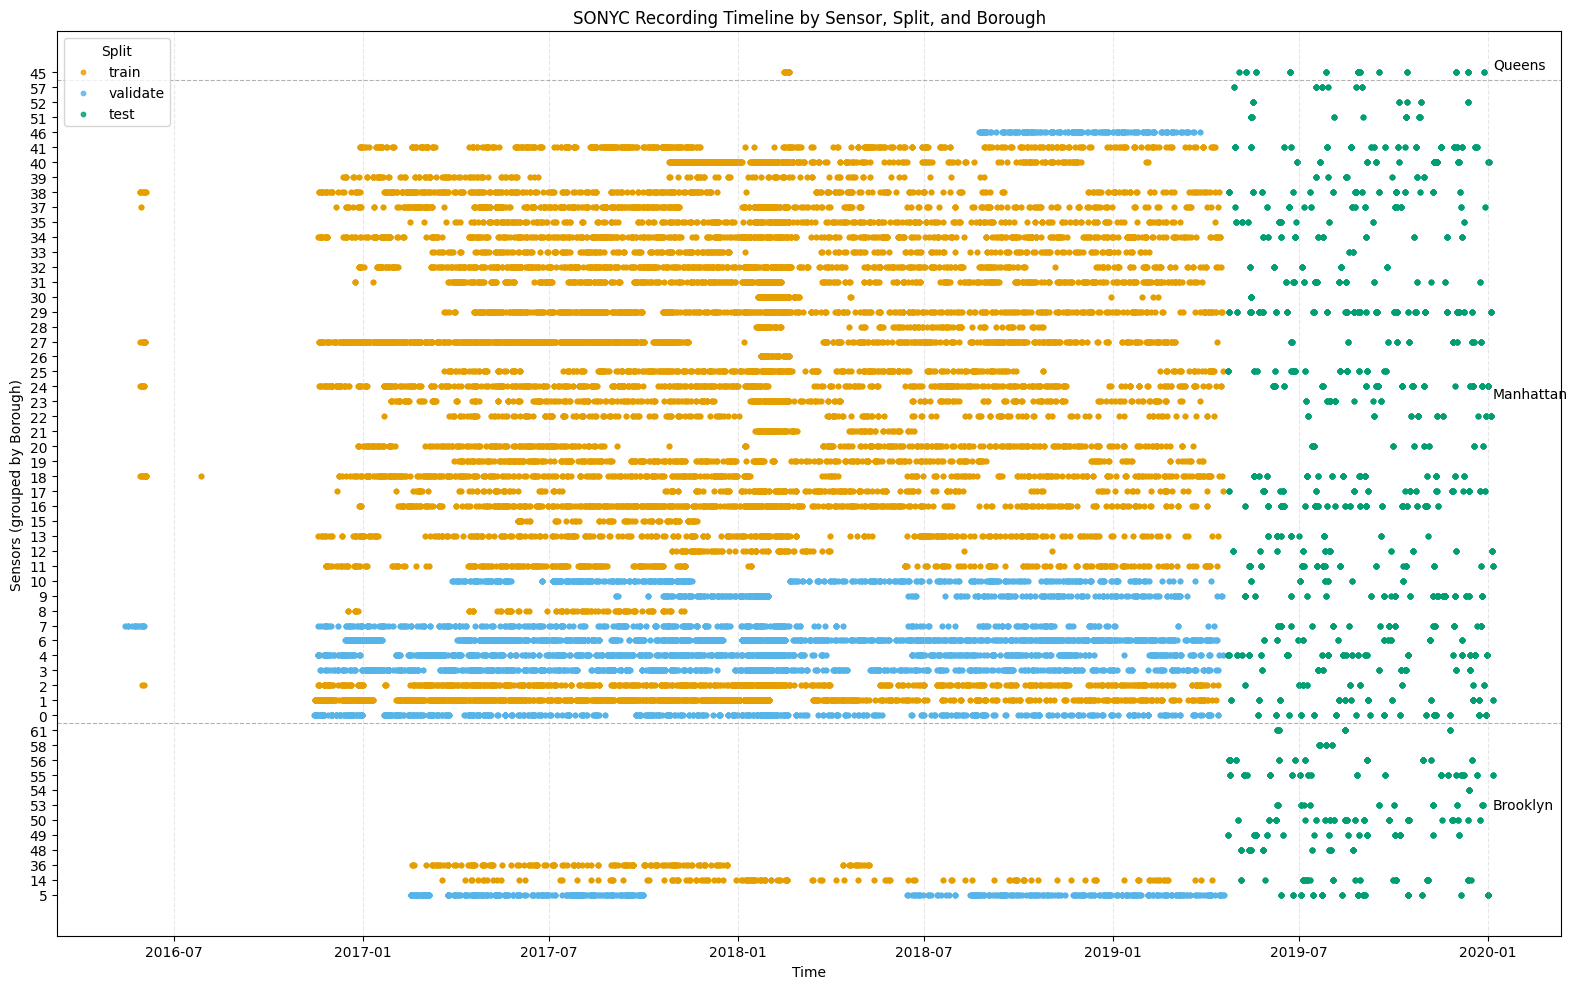

In [8]:
borough_map = {
    1: "Manhattan",
    2: "Bronx",
    3: "Brooklyn",
    4: "Queens",
    5: "Staten Island"
}

annotations_df['borough_name'] = annotations_df['borough'].map(borough_map)

ordered_sensors = (
    annotations_df[['sensor_id', 'borough_name']]
    .drop_duplicates()
    .sort_values(['borough_name', 'sensor_id'])
)

sensor_order = {sid: i for i, sid in enumerate(ordered_sensors['sensor_id'])}
annotations_df['sensor_y'] = annotations_df['sensor_id'].map(sensor_order)

split_colors = {
    'train': '#E69F00',     # orange
    'validate': '#56B4E9',  # sky blue
    'test': '#009E73'       # teal
}

plt.style.use('default')
fig, ax = plt.subplots(figsize=(16, 10))

for split, color in split_colors.items():
    subset = annotations_df[annotations_df['split'] == split]
    ax.scatter(
        subset['datetime'],
        subset['sensor_y'],
        s=10,
        color=color,
        alpha=0.8,
        label=split
    )

borough_boundaries = []
current_borough = None

for i, (_, row) in enumerate(ordered_sensors.iterrows()):
    borough = row['borough_name']
    if borough != current_borough:
        if i != 0:
            borough_boundaries.append(i - 0.5)
        current_borough = borough

for y in borough_boundaries:
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

borough_labels = (
    ordered_sensors.groupby('borough_name')
    .apply(lambda x: sensor_order[x['sensor_id'].iloc[0]] + len(x) / 2)
)

for borough, y in borough_labels.items():
    ax.text(
        annotations_df['datetime'].max(),
        y,
        borough,
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_xlabel("Time")
ax.set_ylabel("Sensors (grouped by Borough)")
ax.set_title("SONYC Recording Timeline by Sensor, Split, and Borough")
ax.set_yticks(list(sensor_order.values()))
ax.set_yticklabels(list(sensor_order.keys()))
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.legend(title="Split", loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------

                         PLOT AND PLAYBACK AUDIO FILES                          

--------------------------------------------------------------------------------
Loaded audio file : /Users/calodii/Desktop/stuff/home/dl4m/noise-bliss/data/sonyc-ust/audio/06_002911.wav
Waveform shape    : (1, 480000)
Sample rate       : 48000 Hz
--------------------------------------------------------------------------------


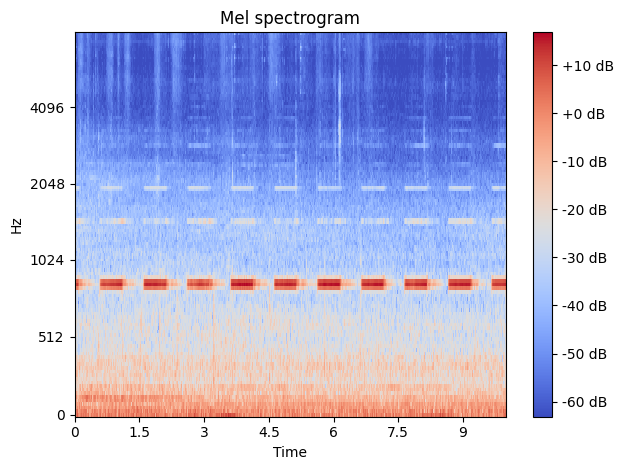

In [9]:
example_audio = random.choice(audio_files)
waveform, sample_rate = torchaudio.load(example_audio)
waveform = waveform.numpy()

print("-" * 80)
title = "PLOT AND PLAYBACK AUDIO FILES"
print("\n" + title.center(80) + "\n")
print("-" * 80)
print(f"Loaded audio file : {example_audio}")
print(f"Waveform shape    : {waveform.shape}")
print(f"Sample rate       : {sample_rate} Hz")
print("-" * 80)

u.mel_spectrogram(
    waveform,
    sample_rate,
    n_mels=128,
    hop_length=512
)

ipd.Audio(example_audio)

#### Creating Datasets

In [10]:
# create datasets
target_shape = (128, 128)
batch_size = 32

# filter audio files by split
train_files = annotations_df[annotations_df['split'] == 'train']['audio_filename'].unique()
val_files = annotations_df[annotations_df['split'] == 'validate']['audio_filename'].unique()
test_files = annotations_df[annotations_df['split'] == 'test']['audio_filename'].unique()

# creating dataset from each split
train = u.data_set(
    [os.path.join(audio_dir, f) for f in train_files],
    batch_size,
    target_shape
)

validation = u.data_set(
    [os.path.join(audio_dir, f) for f in val_files],
    batch_size,
    target_shape
)

train = u.data_set(
    [os.path.join(audio_dir, f) for f in test_files],
    batch_size,
    target_shape,
    shuffle=False
)

#### Training Model

1. Taking the Fourier Transform to understand singal properties. Since this is a complex signal and we are dealing with real time audio it's important to construct an analytical signal using that complex signal using Hilbert's Transform
$$X(\omega) = \int{x(t)e^{-j\omega t}dt}$$

2. Mel Spectrogram Generation
Converts the frequency $(f)$ to mel scale. Power spectrum is $|X(\omega)^2|$. Mel filterbank is the weighted sum of spectral components
$$Mel(f) = 2595 * \log 10( 1 + f/700$$

In [11]:
# multi-lable classification number of classes
# update based on number of classes
num_classes = 8

# creating and compiling
model = m.classification_model(
    input_shape=(128, 128, 1),
    num_classes=num_classes
)

# compiling model and printing summary
model = m.compile_model(model)
model.summary()

# train the model
history = m.train_model(
    model=model,
    train_data=train,
    validation_data=validation,
    epochs=50
)

# plotting results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')

2025-04-14 11:24:33.742092: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-04-14 11:24:33.742127: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-04-14 11:24:33.742132: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1744644273.742146 2652096 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1744644273.742167 2652096 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,512 (32.37 MB)

 Trainable params: 8,484,552 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

AttributeError: 'NoneType' object has no attribute 'shape'